# KeyBERT + MMR Reranker

**전체 파이프라인**
```
KP20K (500 samples)
        ↓
[Stage 1] KeyBART — 후보 키프레이즈 생성
        ↓
[Stage 2] KeyBERT Reranking — 문서-후보 코사인 유사도로 1차 순위
        ↓
[Stage 3] MMR — 의미 중복 제거(다양성 확보)
        ↓
Evaluation — F1@5, F1@M
```

**핵심 아이디어**
- KeyBERT: 임베딩 모델로 문서와 후보 키프레이즈를 인코딩 → 코사인 유사도 기반 1차 순위
- MMR: `λ × relevance - (1-λ) × redundancy` 로 반복 표현 억제, λ로 trade-off 조절

In [1]:
# 필요 패키지 설치
!pip install transformers datasets sentence-transformers scikit-learn nltk -q

## Config — 실험 파라미터

In [2]:
# ── 전체 파이프라인에서 사용할 하이퍼파라미터 ──────────────────────
# 여기서 값을 바꾸면 아래 셀 전체에 반영됩니다.
CONFIG = {
    # ── 데이터 ────────────────────────────────────────────────
    'num_samples': 500,           # 실험에 사용할 샘플 수 (즉시 실행 가능 규모)
    'split': 'test',              # 평가 split ('test' | 'validation')

    # ── KeyBART 후보 생성 ────────────────────────────────────
    'keybart_model': 'bloomberg/KeyBART',
    'num_beams': 10,              # Beam search 너비
    'num_return_sequences': 10,   # 반환 시퀀스 수 (beam 수 이하)
    'keybart_max_len': 60,        # 생성 최대 토큰 수

    # ── KeyBERT 임베딩 모델 ──────────────────────────────────
    # 옵션 A (범용 고성능):  'sentence-transformers/all-mpnet-base-v2'
    # 옵션 B (학술 도메인):  'allenai/scibert_scivocab_uncased'
    'encoder_model': 'sentence-transformers/all-mpnet-base-v2',

    # ── MMR ─────────────────────────────────────────────────
    # λ=1.0 → 순수 relevance (다양성 무시)
    # λ=0.0 → 순수 diversity (relevance 무시)
    # λ=0.5~0.7 → 일반적으로 좋은 균형
    'mmr_lambda': 0.6,

    # ── 출력 / 평가 ──────────────────────────────────────────
    'top_k': 10,                  # MMR이 최종 선택할 키프레이즈 수
    'eval_k': 5,                  # F1@K 에서 K
}

## Imports & Device Setup

In [3]:
import torch
import numpy as np
import nltk

from transformers import BartForConditionalGeneration, AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
from nltk.stem import PorterStemmer
from tqdm.auto import tqdm

nltk.download('punkt', quiet=True)

# GPU 사용 가능 여부 확인
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Stage 1-A: 데이터 로드 (KP20K)

In [4]:
# KP20K 데이터셋 로드
# - title, abstract, keyphrases(gold), prmu 필드 포함
dataset = load_dataset('taln-ls2n/kp20k', trust_remote_code=True)

# CONFIG['num_samples']개 샘플만 사용 (빠른 실험)
eval_data = dataset[CONFIG['split']].select(range(CONFIG['num_samples']))

print(f'Loaded {len(eval_data)} samples from "{CONFIG["split"]}" split')
print('\n[Sample]')
print('Title     :', eval_data[0]['title'])
print('Keyphrases:', eval_data[0]['keyphrases'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


BuilderConfig(name='raw', version=0.0.1, data_dir=None, data_files=None, description='This part of my dataset covers the raw data')
Loaded 500 samples from "test" split

[Sample]
Title     : A feedback vertex set of 2-degenerate graphs
Keyphrases: ['feedback vertex set', '2-degenerate graphs', 'decycling set']


## Stage 1-B: KeyBART 후보 키프레이즈 생성

- `bloomberg/KeyBART` 는 학술 논문 요약 → 키프레이즈 생성에 특화된 BART 모델
- Beam Search로 여러 후보 시퀀스를 생성하고, 세미콜론(`;`)으로 개별 키프레이즈를 분리

In [5]:
# ── KeyBART 모델 & 토크나이저 로드 ─────────────────────────────
print(f'Loading KeyBART: {CONFIG["keybart_model"]} ...')
kp_tokenizer = AutoTokenizer.from_pretrained(CONFIG['keybart_model'])
kp_model = BartForConditionalGeneration.from_pretrained(CONFIG['keybart_model']).to(DEVICE)
kp_model.eval()  # 추론 모드 (dropout 비활성화)
print('KeyBART loaded.')


def generate_candidates(title: str, abstract: str) -> list:
    """
    KeyBART Beam Search로 후보 키프레이즈 생성.

    입력 형식: "<title> . <abstract>"
    출력 형식: KeyBART가 생성한 "kp1;kp2;kp3;..." 를 분리한 리스트

    Args:
        title    : 논문 제목
        abstract : 논문 초록

    Returns:
        중복 제거된 후보 키프레이즈 리스트
    """
    # 제목과 초록을 ' . '로 연결 (KeyBART 학습 포맷)
    text = title + ' . ' + abstract
    inputs = kp_tokenizer(
        text,
        return_tensors='pt',
        max_length=512,
        truncation=True      # 512 토큰 초과 시 잘라냄
    ).to(DEVICE)

    with torch.no_grad():
        outputs = kp_model.generate(
            **inputs,
            num_beams=CONFIG['num_beams'],
            num_return_sequences=CONFIG['num_return_sequences'],
            max_length=CONFIG['keybart_max_len'],
            no_repeat_ngram_size=3,  # 3-gram 반복 생성 방지
        )

    # 각 시퀀스를 디코딩한 뒤 세미콜론(;)으로 개별 키프레이즈 분리
    candidates = []
    for seq in kp_tokenizer.batch_decode(outputs, skip_special_tokens=True):
        for kp in seq.split(';'):
            kp = kp.strip()
            if kp:                   # 빈 문자열 제거
                candidates.append(kp)

    # 중복 제거 (순서 유지: 높은 beam score 순서 보존)
    seen, unique = set(), []
    for kp in candidates:
        if kp not in seen:
            seen.add(kp)
            unique.append(kp)

    return unique

Loading KeyBART: bloomberg/KeyBART ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


KeyBART loaded.


In [6]:
# ── 500개 샘플 전체에 대해 후보 키프레이즈 생성 ─────────────────
# GPU 환경에서 약 5~10분 소요 (CPU는 약 30~60분)
records = []
for sample in tqdm(eval_data, desc='[Stage 1] KeyBART generating'):
    candidates = generate_candidates(sample['title'], sample['abstract'])
    records.append({
        'title':      sample['title'],
        'abstract':   sample['abstract'],
        'keyphrases': sample['keyphrases'],   # gold labels
        'candidates': candidates,             # KeyBART 생성 후보
    })

# 결과 확인
ex = records[0]
print(f'\n[Example]')
print(f'Title    : {ex["title"]}')
print(f'Gold KPs : {ex["keyphrases"]}')
print(f'Cands({len(ex["candidates"])}): {ex["candidates"]}')

[Stage 1] KeyBART generating:   0%|          | 0/500 [00:00<?, ?it/s]


[Example]
Title    : A feedback vertex set of 2-degenerate graphs
Gold KPs : ['feedback vertex set', '2-degenerate graphs', 'decycling set']
Cands(15): ['2-degenerate n -vertex graph', 'feedback vertex set of cardinality', 'polynomial time algorithm', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that this bound is tight', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper', 'we show that this bound is', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that this bound is tight', 'the cardinality of feedback vertex', 'the cardinality of a minimum', 'the cardinality of a feedback', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. key words: feedback vertex sets', '2-degre

## Stage 2: KeyBERT 기반 Reranking

**방식**
1. 임베딩 모델(`all-mpnet-base-v2` 또는 SciBERT)로 문서와 후보 키프레이즈를 각각 인코딩
2. 문서 벡터와 각 후보 벡터 간 **Cosine Similarity** 계산
3. 유사도 내림차순으로 1차 순위 산출

이 단계는 KeyBERT 논문의 핵심 아이디어로, 후보가 원문을 얼마나 잘 대표하는지를 임베딩 공간에서 측정합니다.

In [7]:
# ── 임베딩 모델 로드 ────────────────────────────────────────────
# SentenceTransformer는 mean pooling + 정규화를 자동 처리합니다.
# all-mpnet-base-v2  : 768차원, 범용 문장 임베딩 SOTA (MS MARCO 파인튜닝)
# scibert            : 학술 논문 전용 사전학습, 과학 도메인에서 강점
print(f'Loading encoder: {CONFIG["encoder_model"]} ...')
encoder = SentenceTransformer(CONFIG['encoder_model'])
print('Encoder loaded.')

Loading encoder: sentence-transformers/all-mpnet-base-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder loaded.


In [8]:
def keybert_rank(document: str,
                 candidates: list,
                 encoder: SentenceTransformer) -> tuple:
    """
    KeyBERT 방식으로 후보 키프레이즈를 1차 순위 산출.

    핵심 로직:
        score(doc, kp_i) = cosine_similarity(emb(doc), emb(kp_i))

    Args:
        document   : 원문 텍스트 (title + ' . ' + abstract)
        candidates : KeyBART가 생성한 후보 키프레이즈 리스트
        encoder    : SentenceTransformer 인코더

    Returns:
        ranked_candidates  : (키프레이즈, 유사도) 쌍의 리스트 — 유사도 내림차순
        cand_embeddings    : 후보 임베딩 행렬 (K, H) — MMR에서 재사용
        doc_embedding      : 문서 임베딩 (1, H)     — MMR에서 재사용
    """
    if not candidates:
        return [], np.array([]), np.array([])

    # 1) 문서 임베딩: (1, H)
    doc_embedding = encoder.encode([document], show_progress_bar=False)

    # 2) 후보 키프레이즈 임베딩: (K, H)
    cand_embeddings = encoder.encode(candidates, show_progress_bar=False)

    # 3) 문서-후보 코사인 유사도 계산: (K,)
    #    cosine_similarity는 (n_a, H) × (n_b, H) → (n_a, n_b) 행렬을 반환
    similarities = cosine_similarity(doc_embedding, cand_embeddings)[0]  # (K,)

    # 4) 유사도 내림차순으로 정렬
    ranked_indices = similarities.argsort()[::-1]
    ranked_candidates = [
        (candidates[i], float(similarities[i]))
        for i in ranked_indices
    ]

    return ranked_candidates, cand_embeddings, doc_embedding

## Stage 3: MMR (Maximum Marginal Relevance)

**문제**: 상위 후보들이 의미적으로 유사해 중복 키프레이즈가 선택될 수 있음  
**해결**: MMR로 이미 선택된 키프레이즈와 중복되는 후보에 패널티 부여

$$\text{MMR}_i = \lambda \cdot \underbrace{\text{sim}(d, c_i)}_{\text{relevance}} - (1-\lambda) \cdot \underbrace{\max_{s \in S} \text{sim}(s, c_i)}_{\text{redundancy}}$$

- $d$: 문서 임베딩
- $c_i$: 후보 $i$ 임베딩
- $S$: 이미 선택된 키프레이즈 집합
- $\lambda$: relevance ↔ diversity 균형 (CONFIG에서 조절)

In [9]:
def mmr_rerank(doc_embedding: np.ndarray,
               candidates: list,
               cand_embeddings: np.ndarray,
               mmr_lambda: float = None,
               top_k: int = None) -> list:
    """
    MMR(Maximum Marginal Relevance)로 최종 키프레이즈 선택.

    알고리즘:
        1. 첫 번째 후보: 가장 높은 relevance(문서-후보 유사도)를 가진 것 선택
        2. 이후 반복: MMR 점수가 가장 높은 후보를 greedy하게 선택
           MMR = λ×relevance - (1-λ)×max_redundancy

    Args:
        doc_embedding   : 문서 임베딩 (1, H)
        candidates      : 전체 후보 키프레이즈 리스트
        cand_embeddings : 후보 임베딩 행렬 (K, H)
        mmr_lambda      : relevance-diversity 균형 파라미터 (0~1)
                          None이면 CONFIG['mmr_lambda'] 사용
        top_k           : 최종 선택할 키프레이즈 수
                          None이면 CONFIG['top_k'] 사용

    Returns:
        MMR로 선택된 키프레이즈 리스트 (최대 top_k개)
    """
    # 기본값 처리
    if mmr_lambda is None:
        mmr_lambda = CONFIG['mmr_lambda']
    if top_k is None:
        top_k = CONFIG['top_k']

    if not candidates:
        return []

    # 후보 수가 top_k보다 적으면 top_k를 줄임
    top_k = min(top_k, len(candidates))

    # ── 유사도 행렬 사전 계산 ─────────────────────────────────
    # doc_sim[i]  : 문서와 후보 i의 유사도 (relevance)
    # cand_sim[i][j]: 후보 i와 후보 j의 유사도 (redundancy 측정용)
    doc_sim  = cosine_similarity(doc_embedding, cand_embeddings)[0]    # (K,)
    cand_sim = cosine_similarity(cand_embeddings, cand_embeddings)     # (K, K)

    selected_indices  = []                          # 최종 선택된 후보 인덱스
    remaining_indices = list(range(len(candidates))) # 아직 선택되지 않은 후보

    for _ in range(top_k):
        if not remaining_indices:
            break

        if not selected_indices:
            # ── 첫 번째 선택: relevance가 가장 높은 후보 ──────
            best_idx = max(remaining_indices, key=lambda i: doc_sim[i])
        else:
            # ── 이후 선택: MMR 점수 최대화 ────────────────────
            best_idx, best_score = None, -float('inf')
            for i in remaining_indices:
                # 이미 선택된 후보들과의 최대 유사도 (중복성 측정)
                max_redundancy = max(cand_sim[i][j] for j in selected_indices)

                # MMR 공식: λ × relevance − (1−λ) × redundancy
                mmr_score = mmr_lambda * doc_sim[i] - (1 - mmr_lambda) * max_redundancy

                if mmr_score > best_score:
                    best_score = mmr_score
                    best_idx   = i

        selected_indices.append(best_idx)
        remaining_indices.remove(best_idx)

    return [candidates[i] for i in selected_indices]

## 평가 함수 — F1@K, F1@M

- **F1@5**: 상위 5개 예측 기준 F1  
- **F1@M**: M = gold keyphrase 수 기준 F1 (샘플마다 M이 다름)
- **Stemming**: Porter Stemmer로 어형 변화 정규화 후 비교

In [10]:
stemmer = PorterStemmer()

def stem(phrase: str) -> str:
    """Porter Stemming으로 어형 정규화 (소문자 + 어간 추출)."""
    return ' '.join(stemmer.stem(w) for w in phrase.lower().split())


def f1_at_k(preds: list, golds: list, k: int) -> float:
    """
    F1@K 계산.

    Precision@K = (상위 K 예측 중 정답 수) / K
    Recall@K    = (상위 K 예측 중 정답 수) / (전체 정답 수)
    F1@K        = 2 × P × R / (P + R)

    Args:
        preds : 예측 키프레이즈 리스트 (순위 순)
        golds : 정답 키프레이즈 리스트
        k     : 평가 기준 상위 K

    Returns:
        F1 점수 (0.0 ~ 1.0)
    """
    top_k    = [stem(p) for p in preds[:k]]
    gold_set = {stem(g) for g in golds}

    if not top_k or not gold_set:
        return 0.0

    match     = sum(1 for p in top_k if p in gold_set)
    precision = match / k
    recall    = match / len(gold_set)

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

## 전체 파이프라인 실행 함수

In [11]:
def run_pipeline(records: list,
                 encoder: SentenceTransformer,
                 mmr_lambda: float,
                 top_k: int = None,
                 eval_k: int = None,
                 desc: str = '') -> dict:
    """
    KeyBERT 순위 → MMR → 평가를 한 번에 실행.

    Args:
        records    : build_records()가 반환한 샘플 리스트
        encoder    : SentenceTransformer 인코더
        mmr_lambda : MMR lambda 값
        top_k      : MMR 출력 키프레이즈 수
        eval_k     : F1@K의 K
        desc       : tqdm 표시용 레이블

    Returns:
        {'F1@K': float, 'F1@M': float}
    """
    if top_k  is None: top_k  = CONFIG['top_k']
    if eval_k is None: eval_k = CONFIG['eval_k']

    f1_k_list, f1_m_list = [], []

    for rec in tqdm(records, desc=desc or f'λ={mmr_lambda:.2f}', leave=False):
        document   = rec['title'] + ' . ' + rec['abstract']
        candidates = rec['candidates']
        golds      = rec['keyphrases']

        # 후보가 없으면 0점 처리
        if not candidates:
            f1_k_list.append(0.0)
            f1_m_list.append(0.0)
            continue

        # ── Step 2: KeyBERT — 문서-후보 코사인 유사도로 1차 순위 ──
        _, cand_embeddings, doc_embedding = keybert_rank(document, candidates, encoder)

        # ── Step 3: MMR — 의미 중복 제거 & 최종 top_k 선택 ────────
        final_keyphrases = mmr_rerank(
            doc_embedding   = doc_embedding,
            candidates      = candidates,
            cand_embeddings = cand_embeddings,
            mmr_lambda      = mmr_lambda,
            top_k           = top_k,
        )

        # ── 평가: F1@K, F1@M ───────────────────────────────────
        f1_k = f1_at_k(final_keyphrases, golds, k=eval_k)
        f1_m = f1_at_k(final_keyphrases, golds, k=len(golds))  # M = gold 수

        f1_k_list.append(f1_k)
        f1_m_list.append(f1_m)

    return {
        f'F1@{eval_k}': round(float(np.mean(f1_k_list)), 4),
        'F1@M':         round(float(np.mean(f1_m_list)), 4),
    }

## 실험 1: Baseline vs KeyBERT-only vs KeyBERT+MMR

- **Baseline**: KeyBART 생성 순서 그대로 (reranking 없음)
- **KeyBERT-only**: 코사인 유사도로만 순위 (λ=1.0, diversity 없음)
- **KeyBERT+MMR**: λ=0.6 (추천값)

In [12]:
EVAL_K = CONFIG['eval_k']
MMR_LAM = CONFIG['mmr_lambda']

# ── Baseline: KeyBART 원래 순서 ─────────────────────────────────
# reranking 없이 KeyBART 생성 순서 그대로 평가
print('Running Baseline (KeyBART order)...')
baseline_f1k, baseline_f1m = [], []
for rec in tqdm(records, desc='Baseline', leave=False):
    golds = rec['keyphrases']
    preds = rec['candidates']   # 원래 순서 그대로
    baseline_f1k.append(f1_at_k(preds, golds, k=EVAL_K))
    baseline_f1m.append(f1_at_k(preds, golds, k=len(golds)))

baseline_results = {
    f'F1@{EVAL_K}': round(float(np.mean(baseline_f1k)), 4),
    'F1@M':         round(float(np.mean(baseline_f1m)), 4),
}

# ── KeyBERT-only: λ=1.0 (다양성 없음) ───────────────────────────
print('Running KeyBERT-only (λ=1.0)...')
keybert_only = run_pipeline(records, encoder, mmr_lambda=1.0, desc='KeyBERT-only')

# ── KeyBERT + MMR: λ=CONFIG['mmr_lambda'] ───────────────────────
print(f'Running KeyBERT+MMR (λ={MMR_LAM})...')
mmr_results = run_pipeline(records, encoder, mmr_lambda=MMR_LAM, desc='KeyBERT+MMR')

# ── 결과 출력 ────────────────────────────────────────────────────
print(f'\n{"Method":<25} | {f"F1@{EVAL_K}":>8} | {"F1@M":>8}')
print('-' * 48)
print(f'{"Baseline (KeyBART order)":<25} | {baseline_results[f"F1@{EVAL_K}"]:>8.4f} | {baseline_results["F1@M"]:>8.4f}')
print(f'{"KeyBERT-only (λ=1.0)":<25} | {keybert_only[f"F1@{EVAL_K}"]:>8.4f} | {keybert_only["F1@M"]:>8.4f}')
print(f'{f"KeyBERT+MMR (λ={MMR_LAM})":<25} | {mmr_results[f"F1@{EVAL_K}"]:>8.4f} | {mmr_results["F1@M"]:>8.4f}')

Running Baseline (KeyBART order)...


Baseline:   0%|          | 0/500 [00:00<?, ?it/s]

Running KeyBERT-only (λ=1.0)...


KeyBERT-only:   0%|          | 0/500 [00:00<?, ?it/s]

Running KeyBERT+MMR (λ=0.6)...


KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]


Method                    |     F1@5 |     F1@M
------------------------------------------------
Baseline (KeyBART order)  |   0.1181 |   0.1210
KeyBERT-only (λ=1.0)      |   0.0843 |   0.0812
KeyBERT+MMR (λ=0.6)       |   0.0850 |   0.0866


## 실험 2: λ 값에 따른 성능 변화

λ 값을 0.0 ~ 1.0으로 변화시키며 F1@5, F1@M 추이를 관찰합니다.

In [13]:
# 테스트할 λ 값 목록
lambda_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_results = {}

print(f'Lambda sweep on {len(records)} samples...\n')
print(f'{"λ":>6} | {f"F1@{EVAL_K}":>8} | {"F1@M":>8}')
print('-' * 32)

for lam in lambda_values:
    result = run_pipeline(records, encoder, mmr_lambda=lam)
    sweep_results[lam] = result
    print(f'{lam:>6.2f} | {result[f"F1@{EVAL_K}"]:>8.4f} | {result["F1@M"]:>8.4f}')

# 최적 λ 출력
best_lam = max(sweep_results, key=lambda l: sweep_results[l][f'F1@{EVAL_K}'])
print(f'\nBest λ = {best_lam} → {sweep_results[best_lam]}')

Lambda sweep on 500 samples...

     λ |     F1@5 |     F1@M
--------------------------------


λ=0.00:   0%|          | 0/500 [00:00<?, ?it/s]

  0.00 |   0.0483 |   0.0492


λ=0.20:   0%|          | 0/500 [00:00<?, ?it/s]

  0.20 |   0.0546 |   0.0569


...

  0.80 |   0.0872 |   0.0814


λ=0.90:   0%|          | 0/500 [00:00<?, ?it/s]

  0.90 |   0.0855 |   0.0817


λ=1.00:   0%|          | 0/500 [00:00<?, ?it/s]

  1.00 |   0.0843 |   0.0812

Best λ = 0.8 → {'F1@5': 0.0872, 'F1@M': 0.0814}


## 시각화 — λ vs F1

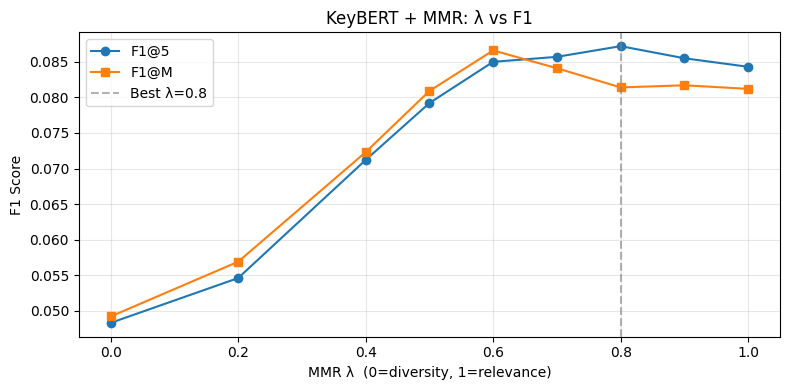

Saved: lambda_sweep.png


In [14]:
import matplotlib.pyplot as plt

lams    = list(sweep_results.keys())
f1k_vals = [sweep_results[l][f'F1@{EVAL_K}'] for l in lams]
f1m_vals = [sweep_results[l]['F1@M']          for l in lams]

plt.figure(figsize=(8, 4))
plt.plot(lams, f1k_vals, marker='o', label=f'F1@{EVAL_K}')
plt.plot(lams, f1m_vals, marker='s', label='F1@M')
plt.axvline(x=best_lam, color='gray', linestyle='--', alpha=0.6, label=f'Best λ={best_lam}')
plt.xlabel('MMR λ  (0=diversity, 1=relevance)')
plt.ylabel('F1 Score')
plt.title('KeyBERT + MMR: λ vs F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=150)
plt.show()
print('Saved: lambda_sweep.png')

## 정성 분석 — 단일 예제 시각화

KeyBERT 1차 순위와 MMR 적용 후 결과를 비교합니다.

In [15]:
def show_example(rec: dict,
                 encoder: SentenceTransformer,
                 mmr_lambda: float,
                 top_k: int = 5):
    """
    단일 샘플의 키프레이즈 추출 과정을 단계별로 출력.

    표시 내용:
        - Gold keyphrases (정답)
        - KeyBERT 1차 순위 (유사도 점수 포함)
        - MMR 최종 선택 (다양성 반영)
    """
    document   = rec['title'] + ' . ' + rec['abstract']
    candidates = rec['candidates']
    golds      = rec['keyphrases']

    # ── KeyBERT 1차 순위 ───────────────────────────────────────
    ranked_cands, cand_embeddings, doc_embedding = keybert_rank(
        document, candidates, encoder
    )

    # ── MMR 적용 ───────────────────────────────────────────────
    mmr_result = mmr_rerank(
        doc_embedding   = doc_embedding,
        candidates      = candidates,
        cand_embeddings = cand_embeddings,
        mmr_lambda      = mmr_lambda,
        top_k           = top_k,
    )

    # ── 출력 ───────────────────────────────────────────────────
    gold_stems = {stem(g) for g in golds}

    print(f'Title   : {rec["title"]}')
    print(f'Gold KPs: {golds}\n')

    print(f'[KeyBERT Top-{top_k}] (유사도 내림차순, before MMR)')
    for kp, score in ranked_cands[:top_k]:
        hit = '✓' if stem(kp) in gold_stems else ' '
        print(f'  {hit} [{score:.4f}] {kp}')

    print(f'\n[MMR Top-{top_k}] (λ={mmr_lambda}, diversity 반영)')
    for kp in mmr_result:
        hit = '✓' if stem(kp) in gold_stems else ' '
        print(f'  {hit} {kp}')

    # 개별 F1 점수
    f1k = f1_at_k(mmr_result, golds, k=EVAL_K)
    f1m = f1_at_k(mmr_result, golds, k=len(golds))
    print(f'\n  F1@{EVAL_K}={f1k:.4f}  F1@M={f1m:.4f}')


# 3개 예제 출력
for i in range(3):
    print(f'\n{"="*65}')
    print(f'[Example {i+1}]')
    show_example(records[i], encoder, mmr_lambda=CONFIG['mmr_lambda'], top_k=CONFIG['eval_k'])


[Example 1]
Title   : A feedback vertex set of 2-degenerate graphs
Gold KPs: ['feedback vertex set', '2-degenerate graphs', 'decycling set']

[KeyBERT Top-5] (유사도 내림차순, before MMR)
    [0.7769] minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that the cardinality of
    [0.7738] minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that the cardinality of
    [0.7586] minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that this bound is tight
    [0.7581] minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that this bound istight
    [0.7539] minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that this bound is tight

[MMR Top-5] (λ=0.6, diversity 반영)
    minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that the cardinality of
    2-degenerate n -vertex graph
    polynomial time algorithm
    feedback ver

## 결과 요약

In [16]:
import pandas as pd

rows = [
    {'Method': 'Baseline (KeyBART order)',              **baseline_results},
    {'Method': 'KeyBERT-only (λ=1.0)',                  **keybert_only},
    {'Method': f'KeyBERT+MMR (λ={CONFIG["mmr_lambda"]})', **mmr_results},
    {'Method': f'KeyBERT+MMR (best λ={best_lam})',      **sweep_results[best_lam]},
]

df = pd.DataFrame(rows).set_index('Method')
display(df)

,F1@5,F1@M
Method,,
Baseline (KeyBART order),0.1181,0.1210
KeyBERT-only (λ=1.0),0.0843,0.0812
KeyBERT+MMR (λ=0.6),0.0850,0.0866
KeyBERT+MMR (best λ=0.8),0.0872,0.0814
